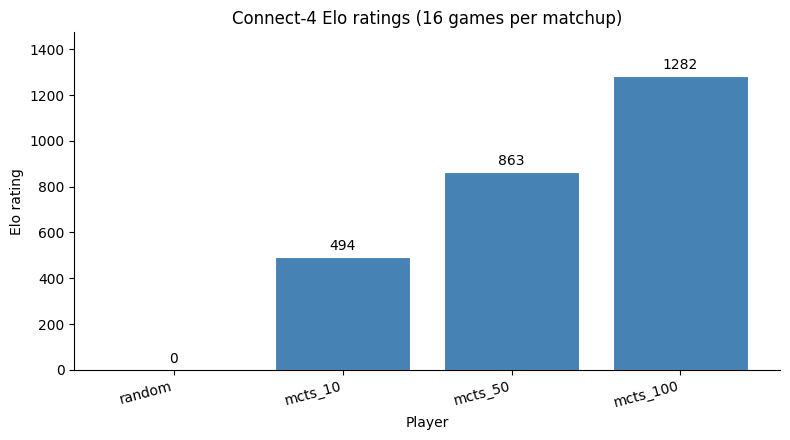

In [8]:
import json

import matplotlib.pyplot as plt
import numpy as np


with open("../../elo_ratings.json", "r") as f:
    elo_ratings = json.load(f)


ratings = elo_ratings["ratings"]
names = list(ratings.keys())
values = [ratings[n] for n in names]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(names, values, color="steelblue", edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="{:.0f}", padding=3)
ax.set_ylabel("Elo rating")
ax.set_xlabel("Player")
ax.set_title(
    f"Connect-4 Elo ratings ({elo_ratings['num_games']} games per matchup)"
)
ax.set_ylim(0, max(values) * 1.15 if values else 1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()



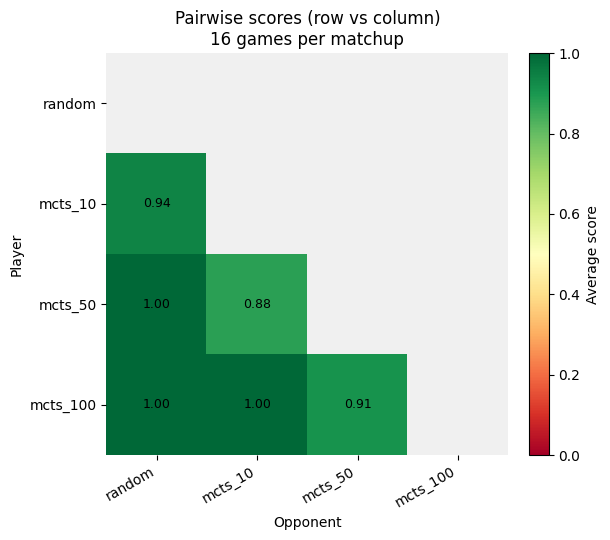

In [9]:
scores = elo_ratings["scores"]
# Keep player order consistent with the ratings plot.
players = list(elo_ratings["ratings"].keys())
n = len(players)
idx = {name: i for i, name in enumerate(players)}

matrix = np.full((n, n), np.nan)
for row_name, opponents in scores.items():
    i = idx[row_name]
    for col_name, score in opponents.items():
        j = idx[col_name]
        matrix[i, j] = score

# Mask upper triangle (and diagonal) so only the stored lower triangle shows.
mask = np.triu(np.ones_like(matrix, dtype=bool))
masked = np.ma.array(matrix, mask=mask)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
cmap = plt.cm.RdYlGn.copy()
cmap.set_bad(color="#f0f0f0")
im = ax.imshow(masked, cmap=cmap, vmin=0.0, vmax=1.0, aspect="equal")

ax.set_xticks(range(n), players, rotation=30, ha="right")
ax.set_yticks(range(n), players)
ax.set_xlabel("Opponent")
ax.set_ylabel("Player")
ax.set_title(
    f"Pairwise scores (row vs column)\n"
    f"{elo_ratings['num_games']} games per matchup"
)

for i in range(n):
    for j in range(n):
        if i > j and not np.isnan(matrix[i, j]):
            ax.text(
                j, i, f"{matrix[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=9,
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Average score")
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()
